In [46]:
import pandas as pd
import pyodbc

In [47]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=sayan-sql-server.database.windows.net;'
    'Database=ecommerce-db;'
    'Uid=azureadmin;'
    'Pwd=Azuresql@2026;'
)

In [48]:
query = """
SELECT *
FROM retail_sales
"""

In [49]:
df = pd.read_sql(query, conn)

print(df.head())

C:\Users\USER\AppData\Local\Temp\ipykernel_37252\2237293752.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2020-152156  2020-11-08  2020-11-11    Second Class    CG-12520   
1       2  CA-2020-152156  2020-11-08  2020-11-11    Second Class    CG-12520   
2       3  CA-2020-138688  2020-06-12  2020-06-16    Second Class    DV-13045   
3       4  US-2019-108966  2019-10-11  2019-10-18  Standard Class    SO-20335   
4       5  US-2019-108966  2019-10-11  2019-10-18  Standard Class    SO-20335   

     Customer_Name    Segment Country_Region             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal_Code  Region       Product_ID         Category Sub_Category  \
0     42420.0   Sout

In [8]:
#Total Revenue:

total_revenue = df["Sales"].sum()

print(total_revenue)

2297200.8558493257


In [9]:
#Total Profit:

total_profit = df["Profit"].sum()

print(total_profit)

286817.020810917


In [10]:
#Profit Margin:

profit_margin = (
    total_profit / total_revenue
) * 100

print(profit_margin)

12.485500346240924


In [11]:
# Region Analysis:

# Revenue by Region:

region_sales = (
     df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.823114
East       678781.237777
Central    501239.889593
South      391721.905365
Name: Sales, dtype: float64


In [13]:
# Top Customers:

top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer_Name
Sean Miller           25043.050486
Tamara Chand          19052.217195
Raymond Buch          15117.338959
Tom Ashbrook          14595.619864
Adrian Barton         14473.571244
Ken Lonsdale          14175.228905
Sanjit Chand          14142.334138
Hunter Lopez          12873.297663
Sanjit Engle          12209.438140
Christopher Conant    12129.071537
Name: Sales, dtype: float64


In [14]:
# SQL Aggregation + Python:

query = """
SELECT
    region,
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit
FROM retail_sales
GROUP BY Region
"""

In [15]:
region_df = pd.read_sql(query, conn)

print(region_df)

    region    total_sales   total_profit
0     East  678781.237777   91522.779816
1    South  391721.905365   47169.430233
2     West  725457.823114  108418.448580
3  Central  501239.889593   39706.362182


C:\Users\USER\AppData\Local\Temp\ipykernel_37252\3197281995.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  region_df = pd.read_sql(query, conn)


In [ ]:
# Benefits:

# Faster SQL processing
# Reduced Python memory usage
# Cleaner analytics workflow

In [16]:
# Create Automated Reports:

#Export KPI Report:

region_df.to_excel(
    "regional_sales_report.xlsx",
    index=False
)

In [17]:
# Export CSV:

region_df.to_csv(
    "regional_sales_report.csv",
    index=False
)

In [19]:
# Basic Visualization:

import matplotlib.pyplot as plt

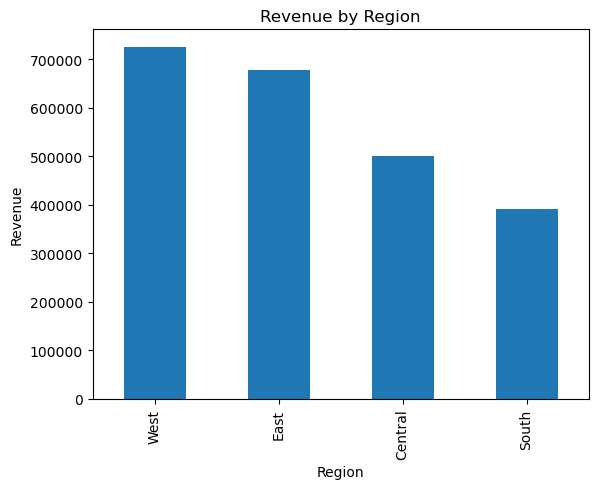

In [20]:
# Revenue by Region Chart:

region_sales.plot(kind="bar")

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

In [34]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])


In [37]:
# Feature engineering:

f["Month"]=df["Order_Date"].dt.month_name()

In [38]:
df["Month"]

0       November
1       November
2           June
3        October
4        October
          ...   
9989     January
9990    February
9991    February
9992    February
9993         May
Name: Month, Length: 9994, dtype: object

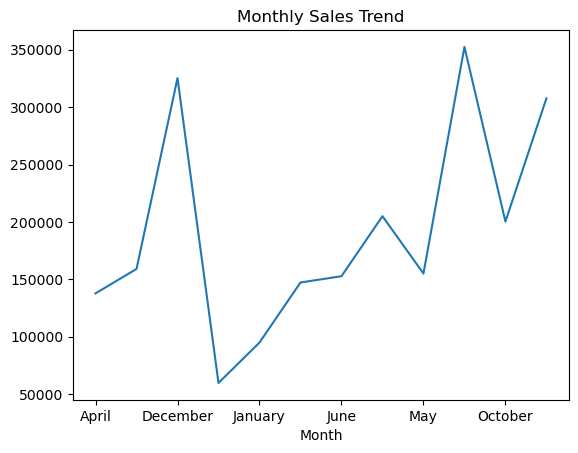

In [40]:
# Monthly Sales Trend:


monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")

plt.show()

In [23]:
# null validation:

print(df.isnull().sum())

Row_ID             0
Order_ID           0
Order_Date         0
Ship_Date          0
Ship_Mode          0
Customer_ID        0
Customer_Name      0
Segment            0
Country_Region     0
City               0
State              0
Postal_Code       11
Region             0
Product_ID         0
Category           0
Sub_Category       0
Product_Name       0
Sales              0
Quantity           0
Discount           0
Profit             1
dtype: int64


In [24]:
# Duplicate Validation:

duplicates = df.duplicated().sum()

print(duplicates)

0


In [26]:
# Negative Sales Validation:

negative_sales = df[df["Sales"] < 0]

print(negative_sales)

Empty DataFrame
Columns: [Row_ID, Order_ID, Order_Date, Ship_Date, Ship_Mode, Customer_ID, Customer_Name, Segment, Country_Region, City, State, Postal_Code, Region, Product_ID, Category, Sub_Category, Product_Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [27]:
# Create Reusable KPI Functions:

def calculate_profit_margin(
    Revenue,
    Profit
):
    return (Profit / Revenue) * 100

In [28]:
# Call Function:

margin = calculate_profit_margin(
    total_revenue,
    total_profit
)

print(margin)

12.485500346240924


In [50]:
# Top products by category:

query = """
SELECT *
FROM (
    SELECT category,
           sub_category,
           SUM(sales) AS total_sales,
           RANK() OVER (PARTITION BY category ORDER BY SUM(sales) DESC) AS rnk
    FROM retail_sales
    GROUP BY category, sub_category
) t
WHERE rnk <= 3
"""

In [51]:
Top_products_per_category = pd.read_sql(query, conn)

print(Top_products_per_category)

          category sub_category    total_sales  rnk
0        Furniture       Chairs  328449.102329    1
1        Furniture       Tables  206965.531607    2
2        Furniture    Bookcases  114879.996025    3
3  Office Supplies      Storage  223843.608764    1
4  Office Supplies      Binders  203412.732438    2
5  Office Supplies   Appliances  107532.161303    3
6       Technology       Phones  330007.054325    1
7       Technology     Machines  189238.631018    2
8       Technology  Accessories  167380.317870    3


C:\Users\USER\AppData\Local\Temp\ipykernel_37252\2610565677.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Top_products_per_category = pd.read_sql(query, conn)
